<a href="https://colab.research.google.com/github/aragaoian/dip-notebooks/blob/master/notebooks/segmentacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2B - Segmentação
**Universidade do Vale do Itajaí** <br>
**Professor**: Felipe Viel <br>
**Alunos**: Ian Callegari Aragão, Lucas Losekann Rosa e Lucas Carvalho Borba <br>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
import cv2
from google.colab.patches import cv2_imshow
from tqdm import tqdm
from queue import Queue
from matplotlib import colors as mcolors
from IPython.display import display, Markdown
import pandas as pd

## Parte 1

Desenvolver uma segmentação usando cluster baseado em K-means para as imagens de maçãs disponíveis no
github da disciplina, implemente segmentação baseada em cluster K-means quando: <br>

A. O espaço de cores tridimensional é usado para agrupamento (RGB) <br>
B. O espaço de 5 dimensões é usado para agrupamento, onde as primeiras 3 dimensões são o espaço de
cores e as duas dimensões extras correspondem às dimensões X e Y da imagem. <br>

Apresente também um gráfico (plot) de dispersão 3D para a imagem (A), ilustrando o agrupamento (mostrado
apenas para imagem fornecida 2or4objects.jpg), sendo que os três eixos são RGB. Além disso, compare e
contraste os resultados da parte (A) e da parte (B). Defina o valor de K adequadamente com base no número de
objetos nas imagens compartilhadas. Essa operação demora para rodar, logo, não deixem para a última hora.

1. https://scispace.com/pdf/color-image-segmentation-using-a-spatial-k-means-clustering-52dr4rhnvz.pdf
2. https://cs.uwaterloo.ca/~yboykov/Courses/cs484_2018/Lectures/lec09_segm_u.pdf

(np.float64(-0.5), np.float64(566.5), np.float64(340.5), np.float64(-0.5))

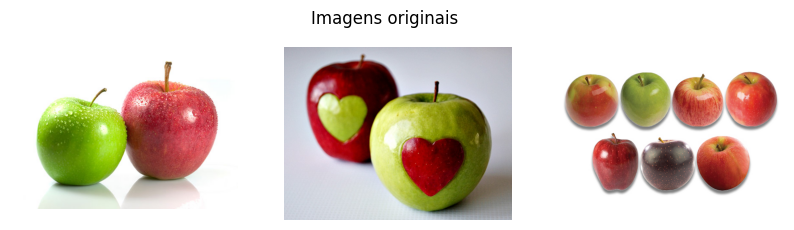

In [ ]:
img1 = cv2.cvtColor(cv2.imread("2apples.jpg"), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread("2or4objects.jpg"), cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(cv2.imread("7apples.jpg"), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,8))
fig.suptitle("Imagens originais", y=0.65)

ax[0].imshow(img1, vmin=0, vmax=255)
ax[0].axis("off")

ax[1].imshow(img2, vmin=0, vmax=255)
ax[1].axis("off")

ax[2].imshow(img3, vmin=0, vmax=255)
ax[2].axis("off")

In [ ]:
def spatial_feature_array(img):
    h, w, c = img.shape
    modified_arr = []
    for x in range(h):
        for y in range(w):
            r, g, b = np.rollaxis(img[x, y], -1)
            modified_arr.append([r, g, b, x, y])

    return np.array(modified_arr, dtype=np.int32)


def plot_3d(
    img, title, spatial_features=False, clusters=[2, 3], ticks=np.arange(0, 255, 50)
):
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle(title, y=0.8)

    # original image
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.imshow(img, vmin=0, vmax=255)
    ax1.set_title("Imagem Original")
    ax1.axis("off")

    ax3d = fig.add_subplot(2, 3, 4, projection="3d")
    r, g, b = np.rollaxis(img, -1)  # extract RGB values from the segmented image
    rgb_colors = (
        np.column_stack((r.flatten(), g.flatten(), b.flatten())) / 255.0
    )  # divided by 255 to norm
    ax3d.scatter(r, g, b, s=1, c=rgb_colors, linewidths=0)
    ax3d.set_xlabel("R")
    ax3d.set_ylabel("G")
    ax3d.set_zlabel("B")
    ax3d.set_xticks(ticks)
    ax3d.set_yticks(ticks)
    ax3d.set_zticks(ticks)

    if not spatial_features:
        img_reshaped = img.reshape(-1, 3)
    else:
        img_reshaped = spatial_feature_array(img=img) * np.array(
            [1, 1, 1, 1 / img.shape[0], 1 / img.shape[1]]
        )  # scale x and y

    for i, cluster in enumerate(clusters, 1):
        kmeans = KMeans(n_clusters=cluster, random_state=0, n_init=10)
        kmeans.fit(img_reshaped)  # fit to compute values

        print(f"Inertia: {kmeans.inertia_}")

        if spatial_features:
            kmeans.cluster_centers_ = np.delete(
                kmeans.cluster_centers_, [3, 4], axis=1
            )  # delete x and y (after fitting, it is no longer important)

        # map each pixel to its corresponding centroid
        img_segmented = np.uint8(
            kmeans.cluster_centers_[kmeans.labels_].reshape(img.shape)
        )

        ax_img = fig.add_subplot(2, 3, i + 1)
        ax_img.imshow(img_segmented, vmin=0, vmax=255)
        ax_img.set_title(f"n_cluster={cluster}")
        ax_img.axis("off")

        ax3d = fig.add_subplot(2, 3, i + 4, projection="3d")
        r_seg, g_seg, b_seg = np.rollaxis(
            img_segmented, -1
        )  # extract RGB values from the segmented image
        rgb_colors = (
            np.column_stack((r_seg.flatten(), g_seg.flatten(), b_seg.flatten())) / 255.0
        )  # divided by 255 to norm
        ax3d.scatter(r, g, b, s=5, c=rgb_colors)
        ax3d.set_xlabel("R")
        ax3d.set_ylabel("G")
        ax3d.set_zlabel("B")
        ax3d.set_xticks(ticks)
        ax3d.set_yticks(ticks)
        ax3d.set_zticks(ticks)

    plt.subplots_adjust(wspace=0.4, hspace=-0.45)
    plt.show()



Inertia: 1551278407.0409033
Inertia: 931974419.2978142


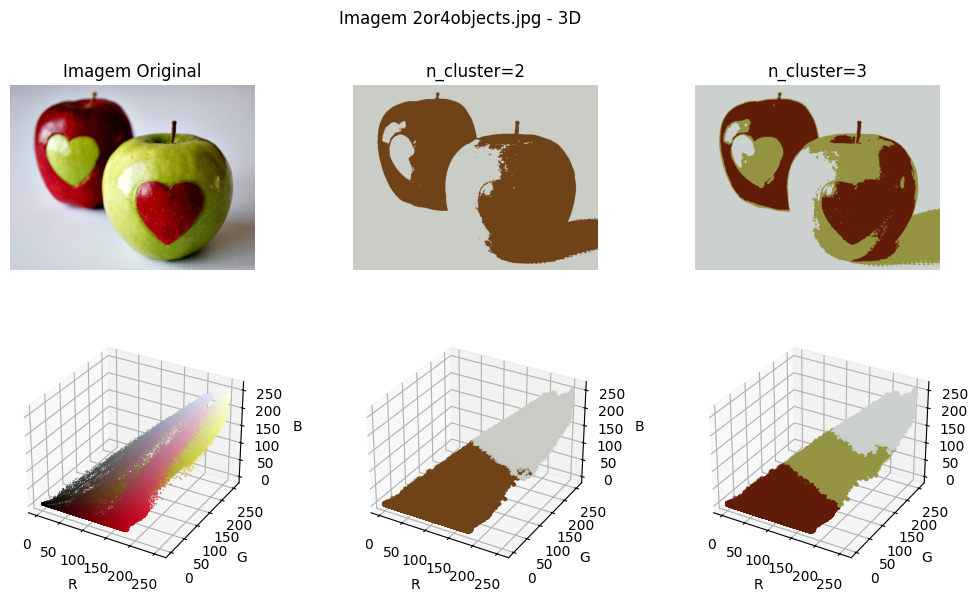

In [ ]:
# A
plot_3d(img2, "Imagem 2or4objects.jpg - 3D")

([<matplotlib.axis.XTick at 0x785708fdc050>,
 [Text(1, 0, '1'),
  Text(3, 0, '3'),
  Text(5, 0, '5'),
  Text(7, 0, '7'),
  Text(9, 0, '9'),
  Text(11, 0, '11'),
  Text(13, 0, '13'),
  Text(15, 0, '15'),
  Text(17, 0, '17')])

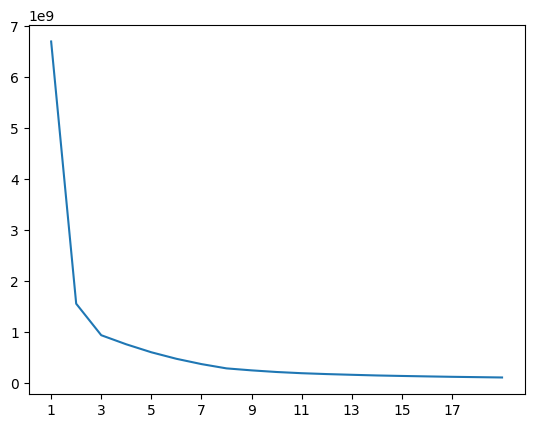

In [ ]:
inertias=[]
for i in range(1,20):
  kmeans=KMeans(n_clusters=i, random_state=0, n_init=10)
  kmeans.fit(img2.reshape(-1, 3))
  inertias.append(kmeans.inertia_)
inertias

plt.plot(range(1,20),inertias)
plt.xticks(np.arange(1, 18, 2))

Inertia: 1551338411.966865
Inertia: 932030006.9272091


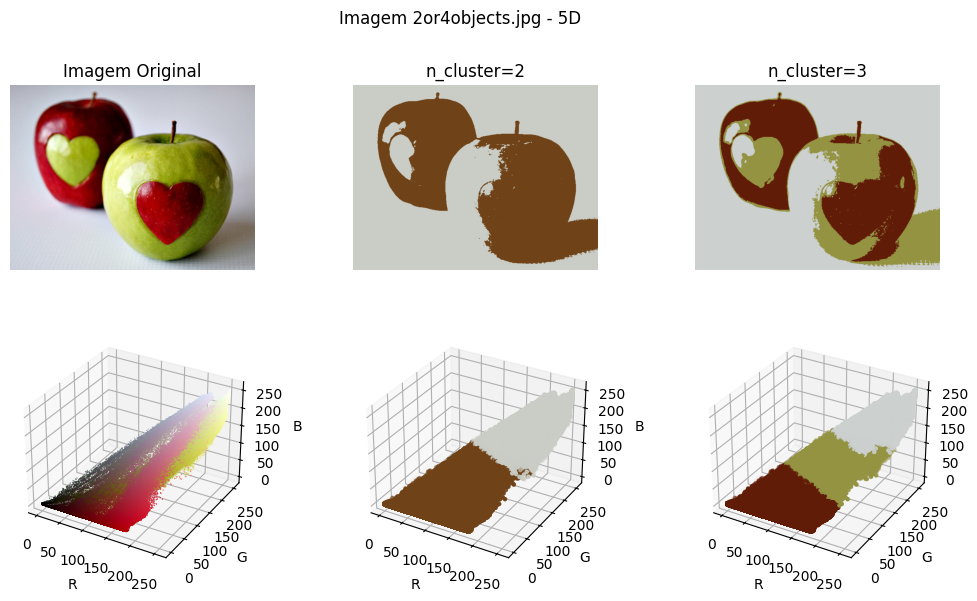

In [ ]:
# B
plot_3d(img2, "Imagem 2or4objects.jpg - 5D", True)

([<matplotlib.axis.XTick at 0x785708dc9b50>,
 [Text(1, 0, '1'),
  Text(3, 0, '3'),
  Text(5, 0, '5'),
  Text(7, 0, '7'),
  Text(9, 0, '9'),
  Text(11, 0, '11'),
  Text(13, 0, '13'),
  Text(15, 0, '15'),
  Text(17, 0, '17')])

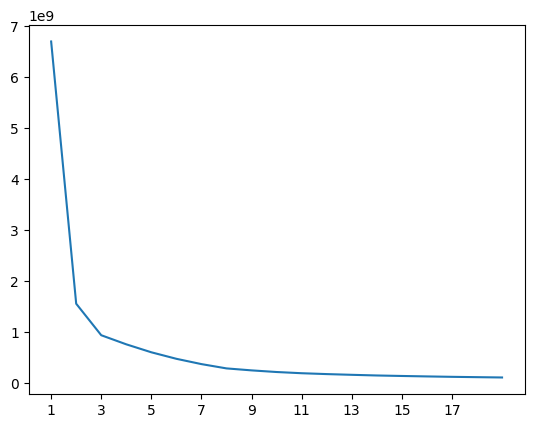

In [ ]:
inertias=[]
for i in range(1,20):
  kmeans=KMeans(n_clusters=i, random_state=0, n_init=10)
  kmeans.fit(spatial_feature_array(img=img2) * np.array(
            [1, 1, 1, 1 / img2.shape[0], 1 / img2.shape[1]]
        ))
  inertias.append(kmeans.inertia_)
inertias

plt.plot(range(1,20),inertias)
plt.xticks(np.arange(1, 18, 2))

## Parte 2

Realizar a detecção de rosto para as imagens de rosto disponíveis no github da disciplina, implemente os seguintes métodos para detecção de rosto: <br>
1. Skin color thresholding: Escolha um intervalo de valores de pixel apropriado para a pele (use suas
habilidades de “pesquisa no Google”). Limite os valores de pixels com base neste intervalo para obter
regiões da pele. Responda a pergunta: para realizar esta operação, RGB é um bom espaço de cores ou
HSV é melhor?. Uma abordagem é apresentada em:
o https://arxiv.org/ftp/arxiv/papers/1708/1708.02694.pdf  <br>

2. Segmentação semeada (Seeded segmentation): Para isso, selecione manualmente um pixel da região
da face. Analise recursivamente a média dos pixels da vizinhança usando a intensidade média de
execução da pele, definindo uma tolerância apropriada. <br>

Dica: pesquise sobre “SeedPointSegmentation”
para encontrar abordagens.
Você também pode testar com mais imagens além do dataset fornecido. Recomendo usar o gerador de faces
que não existe disponíveis na internet. Além disso, vocês devem apresentar uma discussão sobre métricas de
avaliação para segmentação e quais poderiam ser usadas em segmentação sem abordagens de Deep Learning.

1. https://stanford.edu/~cpiech/cs221/handouts/kmeans.html

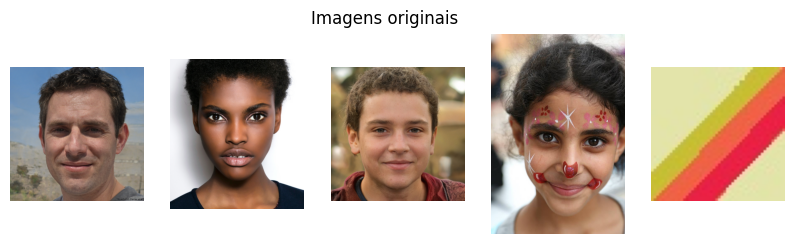

In [ ]:
face1 = cv2.cvtColor(cv2.imread("face1.jpg"), cv2.COLOR_BGR2RGB)
face2 = cv2.cvtColor(cv2.imread("face2.jpg"), cv2.COLOR_BGR2RGB)
face3 = cv2.cvtColor(cv2.imread("face3.jpeg"), cv2.COLOR_BGR2RGB)
face4 = cv2.cvtColor(cv2.imread("face4.jpg"), cv2.COLOR_BGR2RGB)
colors = cv2.cvtColor(cv2.imread("colors.jpg"), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(10,8))
fig.suptitle("Imagens originais", y=0.65)

ax[0].imshow(face1, vmin=0, vmax=255)
ax[0].axis("off")

ax[1].imshow(face2, vmin=0, vmax=255)
ax[1].axis("off")

ax[2].imshow(face3, vmin=0, vmax=255)
ax[2].axis("off")

ax[3].imshow(face4, vmin=0, vmax=255)
ax[3].axis("off")

ax[4].imshow(colors, vmin=0, vmax=255)
ax[4].axis("off")


plt.show()

### Skin Color Thresholding

/tmp/ipython-input-3551316247.py:22: RuntimeWarning: overflow encountered in scalar subtract
  rgb_max - rgb_min > 15, np.abs(R - G) > 15,


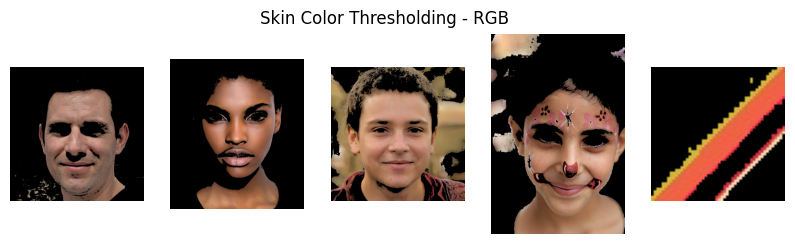

In [ ]:
# RGB
faces = [face1, face2, face3, face4, colors]
facesRGB = []
k = 0

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(10,8))
fig.suptitle("Skin Color Thresholding - RGB", y=0.65)
for i in range(5):
    face = faces[i]
    h, w, c = face.shape
    img_out = np.zeros((h, w, 3), dtype=np.uint8)
    for x in range(h):
        for y in range(w):
            pixel = face[x, y]
            rgb_max = np.maximum.reduce(pixel)
            rgb_min = np.minimum.reduce(pixel)
            R, G, B = pixel

            skin_rule = np.logical_and.reduce([R > 95, G > 40, B > 20,
                                               rgb_max - rgb_min > 15, np.abs(R - G) > 15,
                                               R > G, R > B])
            if skin_rule:
                img_out[x, y] = pixel
            else:
                img_out[x, y] = k
    facesRGB.append(img_out)
    ax[i].imshow(img_out)
    ax[i].axis("off")

plt.show()


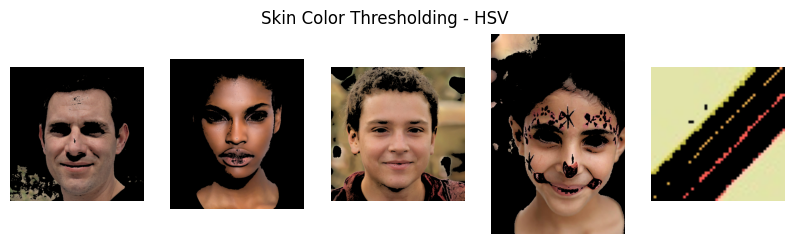

In [ ]:
faces = [face1, face2, face3, face4, colors]
facesHSV = []

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(10,8))
fig.suptitle("Skin Color Thresholding - HSV", y=0.65)

for i in range(5):
    face = faces[i]
    h, w, c = face.shape
    img_out = np.zeros((h, w, 3), dtype=np.uint8)
    img_hsv = cv2.cvtColor(face, cv2.COLOR_RGB2HSV)
    for x in range(h):
        for y in range(w):
            H, S, V = img_hsv[x, y]
            skin_rule = (H >= 0) & (H <= 50) & (S >= 58) & (S <= 173) & (V >= 89) & (V <= 255)

            if skin_rule:
                img_out[x, y] = img_hsv[x, y]
            else:
                img_out[x, y] = 0
    facesHSV.append(cv2.cvtColor(img_out, cv2.COLOR_HSV2RGB))
    ax[i].imshow(cv2.cvtColor(img_out, cv2.COLOR_HSV2RGB))
    ax[i].axis("off")

plt.show()

###Seeded Segmentation

In [ ]:
def checkPoint(img, point, visited):
   #logic to detect if a point was visisted
   if 0 <= point[0] < img.shape[0] and 0 <= point[1] < img.shape[1]:
       if visited[point[0], point[1]] == 1: #
           return 0
       return 1
   return 0

def updatePixel(img, point, tolerance, result, average, count):

   B = abs(float(img[point[0], point[1], 0]) - average[0] / count) # use the absolute value o img in point (band 0) - average index 0 dividade by count
   G = abs(float(img[point[0], point[1], 1]) - average[1] / count)#  use the absolute value o img in point (band 1) - average index 1 dividade by count
   R = abs(float(img[point[0], point[1], 2]) - average[2] / count) # use the absolute value o img in point (band 2) - average index 2 dividade by count

   if B < tolerance and G < tolerance and R < tolerance:
       result[point[0], point[1], 0] = img[point[0], point[1], 0] # receive img in point, but band 0
       result[point[0], point[1], 1] = img[point[0], point[1], 1] # receive img in point, but band 1
       result[point[0], point[1], 2] = img[point[0], point[1], 2] # receive img in point, but band 2
       average[0] += float(img[point[0], point[1], 0]) # receive imge in point, but band 0 - use float cast
       average[1] += float(img[point[0], point[1], 1]) # receive imge in point, but band 1 - use float cast
       average[2] += float(img[point[0], point[1], 2]) # receive imge in point, but band 2 - use float cast
       count += 1
       return 1, result, average, count
   return 0, result, average, count


#Tolerance is 0 - 100
def SeedPointSegmentation(img, seedPoint, tolerance, rgbOut, imgNameOut="out_seed_seg.png"):
   Tolerance = tolerance * 255 / 100 # normalize the value of tolerance to limit of pixel value (eg. 8b is 255)
   Visited = np.zeros((img.shape[0], img.shape[1]), dtype=np.int32)
   Result = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
   Average = [float(img[seedPoint[0], seedPoint[1], 0]), float(img[seedPoint[0], seedPoint[1], 1]), float(img[seedPoint[0], seedPoint[1], 2])]
   Count = 1

   Q = Queue()
   Q.put([seedPoint[0], seedPoint[1]])
   Visited[seedPoint[0], seedPoint[1]] = 1

   while( Q.qsize() > 0 ):
      # print(Q.qsize())
      CurrentPoint = Q.get()
      Ret, Result, Average, Count  = updatePixel(img, CurrentPoint, Tolerance, Result, Average, Count)
      if Ret == 0:
          continue

      p1 = [CurrentPoint[0] + 1, CurrentPoint[1]] #receive a list with [current point index 0 + 1, current point index 1]
      p2 = [CurrentPoint[0] - 1, CurrentPoint[1]] #receive a list with [current point index 0 - 1, current point index 1]
      p3 = [CurrentPoint[0], CurrentPoint[1] - 1] #receive a list with [current point index 0, current point index 1 - 1]
      p4 = [CurrentPoint[0], CurrentPoint[1] + 1] #receive a list with [current point index 0 , current point index 1 + 1]

      if checkPoint(img, p1, Visited):
         Q.put(p1)
         Visited[p1[0], p1[1]] = 1
      if checkPoint(img, p2, Visited):
         Q.put(p2)
         Visited[p2[0], p2[1]]= 1
      if checkPoint(img, p3, Visited):
         Q.put(p3)
         Visited[p3[0], p3[1]]= 1
      if checkPoint(img, p4, Visited):
         Q.put(p4)
         Visited[p4[0], p4[1]] = 1

   return cv2.cvtColor(Result, cv2.COLOR_BGR2RGB) if rgbOut else Result

In [ ]:
ImageList = ["face1.jpg", "face2.jpg", "face3.jpeg", "face4.jpg", "colors.jpg"]

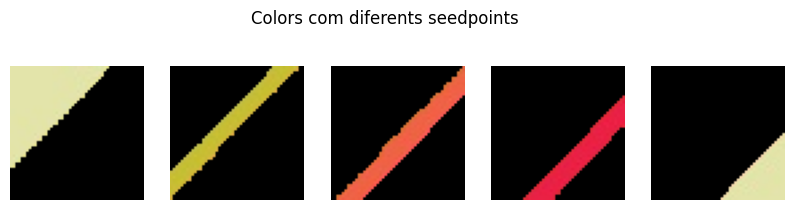

In [ ]:
Image = cv2.imread(ImageList[4])

seedPoints = [[15, 15], [25, 15], [25, 25], [35, 35], [45, 45]]

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(10,8))
fig.suptitle("Colors com diferents seedpoints", y=0.65)

for i in range(5):
  ax[i].imshow(SeedPointSegmentation(Image, seedPoints[i], 10, True), vmin=0, vmax=255)
  ax[i].axis("off")

plt.show()


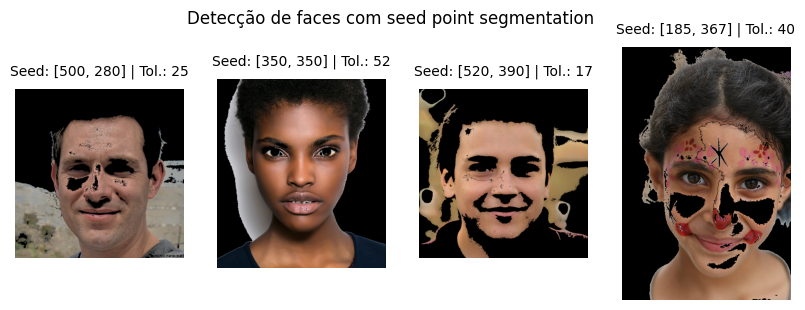

In [ ]:
imgsSeedPoints = [[[500, 280],25],[[350, 350],52],[[520, 390],17],[[185, 367],40]]

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(10,8))
fig.suptitle("Detecção de faces com seed point segmentation", y=0.70)

for i in range(4):
  Image = cv2.imread(ImageList[i])
  ax[i].imshow(SeedPointSegmentation(Image, imgsSeedPoints[i][0], imgsSeedPoints[i][1], True), vmin=0, vmax=255)
  ax[i].set_title(f"Seed: {imgsSeedPoints[i][0]} | Tol.: {imgsSeedPoints[i][1]}", fontsize=10, pad=10)

  ax[i].axis("off")


plt.show()

##Métricas

In [ ]:
def to_float01(img):
    arr = img[..., :3].astype(np.float32)
    if arr.max() > 1.0:
        arr /= 255.0
    return arr

# Regra RGB
def skin_mask_rgb_rule(img):
    I = to_float01(img)
    R, G, B = I[...,0]*255.0, I[...,1]*255.0, I[...,2]*255.0
    maxc = np.max(np.stack([R,G,B], -1), -1)
    minc = np.min(np.stack([R,G,B], -1), -1)
    cond = (R>95) & (G>40) & (B>20) & ((maxc-minc)>15) & (np.abs(R-G)>15) & (R>G) & (R>B)
    return cond.astype(np.uint8)

# Regra HSV
H_MIN, H_MAX = 0.0, 50.0/360.0
S_MIN, S_MAX = 58.0/255.0, 173.0/255.0
V_MIN, V_MAX = 89.0/255.0, 255.0/255.0

def skin_mask_hsv_rule(img):
    I = to_float01(img)
    H, S, V = mcolors.rgb_to_hsv(I).transpose(2,0,1)
    cond = (H>=H_MIN)&(H<=H_MAX)&(S>=S_MIN)&(S<=S_MAX)&(V>=V_MIN)&(V<=V_MAX)
    return cond.astype(np.uint8)

def connected_components_4(mask):
    m = mask.astype(bool)
    H, W = m.shape
    labels = np.zeros((H,W), np.int32)
    current = 0
    nbrs = [(-1,0),(1,0),(0,-1),(0,1)]
    for y in range(H):
        for x in range(W):
            if m[y,x] and labels[y,x]==0:
                current += 1
                stack = [(y,x)]
                labels[y,x] = current
                while stack:
                    cy,cx = stack.pop()
                    for dy,dx in nbrs:
                        ny,nx = cy+dy, cx+dx
                        if 0<=ny<H and 0<=nx<W and m[ny,nx] and labels[ny,nx]==0:
                            labels[ny,nx] = current
                            stack.append((ny,nx))
    return labels, current

def perimeter_4(mask):
    m = mask.astype(bool)
    up    = np.zeros_like(m); up[1:,:]    = m[:-1,:]
    down  = np.zeros_like(m); down[:-1,:] = m[1:,:]
    left  = np.zeros_like(m); left[:,1:]  = m[:,:-1]
    right = np.zeros_like(m); right[:,:-1]= m[:,1:]
    exposed = (m & (~up)) + (m & (~down)) + (m & (~left)) + (m & (~right))
    return float(exposed.sum())

def compactness(area, perim):
    return 0.0 if perim<=0 or area<=0 else float(4.0*np.pi*area/(perim**2))

def edge_gradient_strength(img, mask):
    V = mcolors.rgb_to_hsv(to_float01(img))[...,2]
    gy, gx = np.gradient(V)
    gm = np.hypot(gx, gy)
    m = mask.astype(bool)
    up    = np.zeros_like(m); up[1:,:]    = m[:-1,:]
    down  = np.zeros_like(m); down[:-1,:] = m[1:,:]
    left  = np.zeros_like(m); left[:,1:]  = m[:,:-1]
    right = np.zeros_like(m); right[:,:-1]= m[:,1:]
    boundary = m & (~(up & down & left & right))
    return 0.0 if boundary.sum()==0 else float(gm[boundary].mean())

def metrics_for_mask(img, mask):
    mask = (mask>0).astype(np.uint8)
    labels, n = connected_components_4(mask)
    areas = np.bincount(labels.ravel())
    areas = areas[1:] if len(areas)>1 else np.array([], int)
    total = int(mask.sum())
    if total==0:
        return {"CC":int(n),"Dominance":0.0,"Compactness":0.0,"VarV":0.0,"EdgeGrad":0.0,"Area":0}
    amax = int(areas.max()) if areas.size else 0
    if areas.size:
        largest_label = 1+int(np.argmax(areas))
        perim = perimeter_4(labels==largest_label)
        comp = compactness(amax, perim)
    else:
        comp = 0.0
    V = mcolors.rgb_to_hsv(to_float01(img))[...,2]
    var_v = float(np.var(V[mask.astype(bool)])) if total>0 else 0.0
    eg = edge_gradient_strength(img, mask)
    return {"CC":int(n),"Dominance":float(amax/total),"Compactness":comp,"VarV":var_v,"EdgeGrad":eg,"Area":total}

faces = []
for nm in ("face1","face2","face3","face4", "colors"):
    if nm in globals() and isinstance(globals()[nm], np.ndarray) and globals()[nm].ndim==3:
        faces.append((nm, globals()[nm][...,:3]))
if not faces:
    raise RuntimeError("Carregue 'face1'..'face4' antes desta célula.")

rows = []
for name, img in faces:
    m_rgb = skin_mask_rgb_rule(img)
    m_hsv = skin_mask_hsv_rule(img)

    met_rgb = metrics_for_mask(img, m_rgb)
    met_hsv = metrics_for_mask(img, m_hsv)

    rows += [
        {"Image":name,"Method":"RGB", **met_rgb},
        {"Image":name,"Method":"HSV", **met_hsv},
    ]

    # original | overlay RGB | overlay HSV
    I = to_float01(img)
    overlay_rgb = I * m_rgb[...,None]
    overlay_hsv = I * m_hsv[...,None]
    comp = np.hstack([I, overlay_rgb, overlay_hsv])
    # plt.figure(figsize=(10, 3.6))
    # plt.imshow(np.clip(comp,0,1))
    # plt.axis("off")
    # plt.title(f"{name}: original | RGB mask | HSV mask")
    # plt.show()

df = pd.DataFrame(rows)[["Image","Method","CC","Dominance","Compactness","VarV","EdgeGrad","Area"]]
for c in ["Dominance","Compactness","VarV","EdgeGrad"]:
    df[c] = df[c].astype(float).round(4)

# Mostrar a tabela com as métricas de cada imagem
display(Markdown("### Métricas por imagem (RGB vs HSV)"))
for name,_ in faces:
    display(Markdown(f"**{name}**"))
    display(Markdown(df[df["Image"]==name].reset_index(drop=True).to_markdown(index=False)))

# Output em csv
out_csv = "skin_threshold_metrics.csv"
df.to_csv(out_csv, index=False)
display(Markdown(f"**Arquivo com todas as métricas:** `{out_csv}`"))


### Métricas por imagem (RGB vs HSV)

**face1**

| Image   | Method   |   CC |   Dominance |   Compactness |   VarV |   EdgeGrad |   Area |
|:--------|:---------|-----:|------------:|--------------:|-------:|-----------:|-------:|
| face1   | RGB      |  422 |      0.9817 |        0.0416 | 0.0134 |     0.0226 | 395470 |
| face1   | HSV      |  538 |      0.9374 |        0.0509 | 0.014  |     0.0228 | 423445 |

**face2**

| Image   | Method   |   CC |   Dominance |   Compactness |   VarV |   EdgeGrad |   Area |
|:--------|:---------|-----:|------------:|--------------:|-------:|-----------:|-------:|
| face2   | RGB      |  424 |      0.9912 |        0.056  | 0.0189 |     0.0695 | 194267 |
| face2   | HSV      |  666 |      0.9681 |        0.0289 | 0.0203 |     0.0536 | 192926 |

...

**face4**

| Image   | Method   |   CC |   Dominance |   Compactness |   VarV |   EdgeGrad |   Area |
|:--------|:---------|-----:|------------:|--------------:|-------:|-----------:|-------:|
| face4   | RGB      |  142 |      0.8918 |        0.0535 | 0.0176 |     0.0524 | 120319 |
| face4   | HSV      |  234 |      0.9052 |        0.0315 | 0.0183 |     0.0458 | 108699 |

**colors**

| Image   | Method   |   CC |   Dominance |   Compactness |   VarV |   EdgeGrad |   Area |
|:--------|:---------|-----:|------------:|--------------:|-------:|-----------:|-------:|
| colors  | RGB      |    3 |      0.8658 |        0.4405 | 0.0038 |     0.065  |    760 |
| colors  | HSV      |   54 |      0.4923 |        0.2234 | 0.0038 |     0.0758 |    130 |

**Arquivo com todas as métricas:** `skin_threshold_metrics.csv`